In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os

In [3]:
musiccaps_root = "/kaggle/input/datasets/ayushsharma4045/musiccapsaudio5308"
print(os.listdir(musiccaps_root))

['audio_captions.csv', 'audioFiles']


In [4]:
import pandas as pd

musiccaps_root = "/kaggle/input/datasets/ayushsharma4045/musiccapsaudio5308"
captions_df = pd.read_csv(f"{musiccaps_root}/audio_captions.csv")

print(captions_df.columns.tolist())
print(captions_df.shape)
print(captions_df.head())

['audioFile', 'caption']
(5308, 2)
         audioFile                                            caption
0  -0Gj8-vB1q4.wav  The low quality recording features a ballad so...
1  -0SdAVK79lg.wav  This song features an electric guitar as the m...
2  -0vPFx-wRRI.wav  a male voice is singing a melody with changing...
3  -0xzrMun0Rs.wav  This song contains digital drums playing a sim...
4  -1LrH01Ei1w.wav  This song features a rubber instrument being p...


In [5]:
audio_dir_musiccaps = f"{musiccaps_root}/audioFiles/audioFiles"
captions_df["mp3_path"] = captions_df["audioFile"].apply(lambda f: f"{audio_dir_musiccaps}/{f}")
captions_df["exists"] = captions_df["mp3_path"].apply(os.path.exists)

print("Files found:", captions_df["exists"].sum(), "/", len(captions_df))
captions_df = captions_df[captions_df["exists"]].reset_index(drop=True)

Files found: 5308 / 5308


In [6]:
caption_lengths = captions_df["caption"].str.split().str.len()
print("Caption word count — min:", caption_lengths.min(), "max:", caption_lengths.max(), "mean:", caption_lengths.mean().round(1))

Caption word count — min: 4 max: 136 mean: 49.0


In [7]:
from sklearn.model_selection import train_test_split

captions_df["clip_id"] = captions_df.index

mc_train, mc_temp = train_test_split(captions_df, test_size=0.3, random_state=42)
mc_val, mc_test = train_test_split(mc_temp, test_size=0.5, random_state=42)

print("Train:", len(mc_train), "Val:", len(mc_val), "Test:", len(mc_test))

Train: 3715 Val: 796 Test: 797


In [9]:
!pip install -q torch_geometric


import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool
from transformers import AutoTokenizer, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.1 MB/s eta 0:00:00a 0:00:01
Device: cuda


In [10]:
def load_audio(path, sr=22050):
    import librosa
    y, sr = librosa.load(path, sr=sr, mono=True)
    return y, sr

def get_melspectrogram(y, sr, n_mels=128):
    import librosa
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    log_mel = librosa.power_to_db(mel, ref=1.0).T
    mean = log_mel.mean(axis=0, keepdims=True)
    std = log_mel.std(axis=0, keepdims=True) + 1e-8
    return (log_mel - mean) / std

def split_into_segments(feature_matrix, sr, hop_length=512, window_seconds=2.0):
    frames_per_segment = max(1, int(window_seconds * sr / hop_length))
    segments = []
    for start in range(0, feature_matrix.shape[0], frames_per_segment):
        chunk = feature_matrix[start:start + frames_per_segment]
        if len(chunk) > 0:
            segments.append(chunk.mean(axis=0))
    return segments

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

def build_segment_graph(segments, similarity_threshold=0.5):
    n = len(segments)
    edges = set()
    for i in range(n - 1):
        edges.add((i, i + 1))
    for i in range(n):
        for j in range(i + 1, n):
            if cosine_similarity(segments[i], segments[j]) > similarity_threshold:
                edges.add((i, j))
    return list(edges)


class GNNEncoder(nn.Module):
    def __init__(self, in_dim=128, hidden_dim=128, num_layers=3, dropout=0.2):
        super().__init__()
        self.convs = nn.ModuleList()
        dims = [in_dim] + [hidden_dim] * num_layers
        for i in range(num_layers):
            self.convs.append(SAGEConv(dims[i], dims[i + 1]))
        self.dropout = dropout
        self.out_dim = hidden_dim
    def forward(self, x, edge_index, batch):
        h = x
        for i, conv in enumerate(self.convs):
            h = conv(h, edge_index)
            if i < len(self.convs) - 1:
                h = torch.relu(h)
                h = nn.functional.dropout(h, p=self.dropout, training=self.training)
        return global_mean_pool(h, batch)

In [11]:
def process_and_cache_musiccaps_clip(mp3_path, save_path, window_seconds=2.0):
    y, sr = load_audio(mp3_path)
    mel = get_melspectrogram(y, sr)
    segments = split_into_segments(mel, sr, window_seconds=window_seconds)
    edges = build_segment_graph(segments)
    x = torch.tensor(np.array(segments), dtype=torch.float32)
    edge_index = torch.tensor([[0], [0]], dtype=torch.long) if len(edges) == 0 else torch.tensor(edges, dtype=torch.long).t().contiguous()
    torch.save(Data(x=x, edge_index=edge_index), save_path)

In [12]:
import time
sample = captions_df["mp3_path"].iloc[:50].tolist()
start = time.time()
for path in sample:
    y, sr = load_audio(path)
    mel = get_melspectrogram(y, sr)
    segs = split_into_segments(mel, sr)
elapsed = time.time() - start
print(f"{elapsed:.1f}s for 50 clips -> {elapsed/50:.3f}s/clip -> est. {elapsed/50*5308/60:.1f} min for all 5,308")

14.5s for 50 clips -> 0.290s/clip -> est. 25.7 min for all 5,308


In [13]:
os.makedirs("data/processed/musiccaps", exist_ok=True)
start = time.time()
processed, failed = 0, 0
for i, row in captions_df.iterrows():
    save_path = f"data/processed/musiccaps/{row['clip_id']}.pt"
    if os.path.exists(save_path):
        continue
    try:
        process_and_cache_musiccaps_clip(row["mp3_path"], save_path)
        processed += 1
    except Exception as e:
        failed += 1
        print(f"Failed on {row['mp3_path']}: {e}")
    if (i + 1) % 1000 == 0:
        print(f"{i+1}/{len(captions_df)} | {processed} processed, {failed} failed | {(time.time()-start)/60:.1f} min")

print(f"Done. Processed {processed}, failed {failed}. Total: {(time.time()-start)/60:.1f} min")

1000/5308 | 1000 processed, 0 failed | 0.9 min
2000/5308 | 2000 processed, 0 failed | 1.9 min
3000/5308 | 3000 processed, 0 failed | 2.9 min
4000/5308 | 4000 processed, 0 failed | 3.9 min
5000/5308 | 5000 processed, 0 failed | 4.8 min
Done. Processed 5308, failed 0. Total: 5.1 min


In [14]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased")

def freeze_bottom_layers(bert, num_layers_to_freeze=8):
    for param in bert.embeddings.parameters():
        param.requires_grad = False
    for layer in bert.encoder.layer[:num_layers_to_freeze]:
        for param in layer.parameters():
            param.requires_grad = False

freeze_bottom_layers(bert, num_layers_to_freeze=8)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
class DualEncoder(nn.Module):
    def __init__(self, gnn_encoder, bert_model, projection_dim=128):
        super().__init__()
        self.gnn = gnn_encoder
        self.bert = bert_model
        self.graph_proj = nn.Linear(gnn_encoder.out_dim, projection_dim)
        self.text_proj = nn.Linear(bert_model.config.hidden_size, projection_dim)

    def encode_graph(self, x, edge_index, batch):
        graph_vector = self.gnn(x, edge_index, batch)
        projected = self.graph_proj(graph_vector)
        return nn.functional.normalize(projected, dim=-1)  # unit length, so dot product = cosine similarity

    def encode_text(self, input_ids, attention_mask):
        cls_vector = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        projected = self.text_proj(cls_vector)
        return nn.functional.normalize(projected, dim=-1)

    def forward(self, graph_x, graph_edge_index, graph_batch, input_ids, attention_mask):
        g = self.encode_graph(graph_x, graph_edge_index, graph_batch)
        t = self.encode_text(input_ids, attention_mask)
        return g, t

In [17]:
def info_nce_loss(g, t, temperature=0.07):

    logits = g @ t.t() / temperature
    labels = torch.arange(g.size(0), device=g.device)
    loss_g_to_t = nn.functional.cross_entropy(logits, labels)
    loss_t_to_g = nn.functional.cross_entropy(logits.t(), labels)
    return (loss_g_to_t + loss_t_to_g) / 2

In [18]:
class MusicCapsDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        graph = torch.load(f"data/processed/musiccaps/{row['clip_id']}.pt", weights_only=False)
        tokens = self.tokenizer(
            row["caption"], padding="max_length", truncation=True,
            max_length=self.max_length, return_tensors="pt",
        )
        graph.input_ids = tokens["input_ids"]
        graph.attention_mask = tokens["attention_mask"]
        return graph

In [19]:
train_mc_dataset = MusicCapsDataset(mc_train, tokenizer, max_length=128)
train_mc_loader = GeoDataLoader(train_mc_dataset, batch_size=32, shuffle=True)

batch = next(iter(train_mc_loader))
batch = batch.to(device)

gnn_encoder = GNNEncoder(in_dim=128, hidden_dim=128, num_layers=3)
model = DualEncoder(gnn_encoder, bert, projection_dim=128).to(device)

g, t = model(batch.x, batch.edge_index, batch.batch, batch.input_ids, batch.attention_mask)
print("Graph embeddings shape:", g.shape)
print("Text embeddings shape:", t.shape)

loss = info_nce_loss(g, t)
print("Loss:", loss.item())

Graph embeddings shape: torch.Size([32, 128])
Text embeddings shape: torch.Size([32, 128])
Loss: 3.565202236175537


In [21]:
val_mc_dataset = MusicCapsDataset(mc_val, tokenizer, max_length=128)
test_mc_dataset = MusicCapsDataset(mc_test, tokenizer, max_length=128)

val_mc_loader = GeoDataLoader(val_mc_dataset, batch_size=32, shuffle=False)
test_mc_loader = GeoDataLoader(test_mc_dataset, batch_size=32, shuffle=False)

In [22]:
@torch.no_grad()
def get_all_embeddings(model, loader, device):
    model.eval()
    all_g, all_t = [], []
    for batch in loader:
        batch = batch.to(device)
        g, t = model(batch.x, batch.edge_index, batch.batch, batch.input_ids, batch.attention_mask)
        all_g.append(g.cpu())
        all_t.append(t.cpu())
    return torch.cat(all_g), torch.cat(all_t)


def compute_retrieval_metrics(g, t, ks=(1, 5, 10)):

    sim = t @ g.t()  # rows = captions, cols = audio
    n = sim.size(0)
    results = {}
    for k in ks:
        k_eff = min(k, n)
        topk = sim.topk(k_eff, dim=1).indices
        hits = (topk == torch.arange(n).unsqueeze(1)).any(dim=1)
        results[f"caption_to_audio_R@{k}"] = hits.float().mean().item()

    sim_rev = g @ t.t()
    for k in ks:
        k_eff = min(k, n)
        topk = sim_rev.topk(k_eff, dim=1).indices
        hits = (topk == torch.arange(n).unsqueeze(1)).any(dim=1)
        results[f"audio_to_caption_R@{k}"] = hits.float().mean().item()
    return results

In [23]:
def train_task4(train_loader, val_loader, device, num_epochs=30, patience=6, temperature=0.07):

    
    gnn_encoder = GNNEncoder(in_dim=128, hidden_dim=128, num_layers=3, dropout=0.2)
    bert_model = AutoModel.from_pretrained("bert-base-uncased")
    freeze_bottom_layers(bert_model, num_layers_to_freeze=8)
    model = DualEncoder(gnn_encoder, bert_model, projection_dim=128).to(device)

    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)
    

    best_val_r5, best_state, best_epoch, epochs_without_improvement = 0.0, None, None, 0
    history = []


    
    for epoch in range(num_epochs):
        
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            g, t = model(batch.x, batch.edge_index, batch.batch, batch.input_ids, batch.attention_mask)
            loss = info_nce_loss(g, t, temperature)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()

        

        val_g, val_t = get_all_embeddings(model, val_loader, device)
        val_metrics = compute_retrieval_metrics(val_g, val_t)
        avg_r5 = (val_metrics["caption_to_audio_R@5"] + val_metrics["audio_to_caption_R@5"]) / 2

        history.append({"epoch": epoch + 1, "train_loss": total_loss / len(train_loader), **val_metrics})
        print(f"Epoch {epoch+1} | loss: {total_loss/len(train_loader):.4f} | "
              f"val C->A R@5: {val_metrics['caption_to_audio_R@5']:.4f} | val A->C R@5: {val_metrics['audio_to_caption_R@5']:.4f}")

        if avg_r5 > best_val_r5:
            best_val_r5, best_epoch = avg_r5, epoch + 1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"No improvement for {patience} epochs — stopping at epoch {epoch+1}.")
                break

    model.load_state_dict(best_state)
    return model, history, best_epoch

In [24]:
mc_model, mc_history, mc_best_epoch = train_task4(train_mc_loader, val_mc_loader, device, num_epochs=30, patience=6)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 | loss: 3.4328 | val C->A R@5: 0.0075 | val A->C R@5: 0.0163
Epoch 2 | loss: 3.2956 | val C->A R@5: 0.0201 | val A->C R@5: 0.0226
Epoch 3 | loss: 3.1954 | val C->A R@5: 0.0264 | val A->C R@5: 0.0327
Epoch 4 | loss: 3.1240 | val C->A R@5: 0.0276 | val A->C R@5: 0.0314
Epoch 5 | loss: 3.0501 | val C->A R@5: 0.0264 | val A->C R@5: 0.0289
Epoch 6 | loss: 2.9740 | val C->A R@5: 0.0289 | val A->C R@5: 0.0352
Epoch 7 | loss: 2.8777 | val C->A R@5: 0.0339 | val A->C R@5: 0.0289
Epoch 8 | loss: 2.7786 | val C->A R@5: 0.0264 | val A->C R@5: 0.0276
Epoch 9 | loss: 2.6537 | val C->A R@5: 0.0327 | val A->C R@5: 0.0264
Epoch 10 | loss: 2.5474 | val C->A R@5: 0.0289 | val A->C R@5: 0.0364
Epoch 11 | loss: 2.4355 | val C->A R@5: 0.0327 | val A->C R@5: 0.0289
Epoch 12 | loss: 2.3154 | val C->A R@5: 0.0226 | val A->C R@5: 0.0289
Epoch 13 | loss: 2.1594 | val C->A R@5: 0.0251 | val A->C R@5: 0.0264
Epoch 14 | loss: 2.0667 | val C->A R@5: 0.0314 | val A->C R@5: 0.0276
Epoch 15 | loss: 1.9534 | val

In [25]:
test_g, test_t = get_all_embeddings(mc_model, test_mc_loader, device)
test_metrics = compute_retrieval_metrics(test_g, test_t)
print("Test retrieval metrics:", test_metrics)

Test retrieval metrics: {'caption_to_audio_R@1': 0.005018820520490408, 'caption_to_audio_R@5': 0.030112924054265022, 'caption_to_audio_R@10': 0.05646173283457756, 'audio_to_caption_R@1': 0.006273525767028332, 'audio_to_caption_R@5': 0.025094103068113327, 'audio_to_caption_R@10': 0.04516938701272011}


In [27]:
import os
for folder in ["results/checkpoints", "results/plots"]:
    os.makedirs(folder, exist_ok=True)

In [28]:
import json

torch.save(mc_model.state_dict(), "results/checkpoints/task4_contrastive.pt")
with open("results/task4_training_history.json", "w") as f:
    json.dump(mc_history, f, indent=2)
with open("results/metrics_task4.json", "w") as f:
    json.dump(test_metrics, f, indent=2, default=float)
print("Saved.")

Saved.


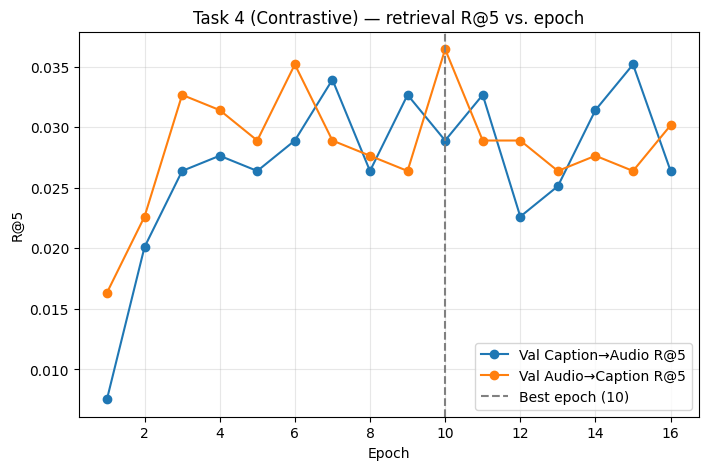

In [31]:
import matplotlib.pyplot as plt


epochs_list = [h["epoch"] for h in mc_history]
plt.figure(figsize=(8, 5))
plt.plot(epochs_list, [h["caption_to_audio_R@5"] for h in mc_history], marker="o", label="Val Caption→Audio R@5")
plt.plot(epochs_list, [h["audio_to_caption_R@5"] for h in mc_history], marker="o", label="Val Audio→Caption R@5")
plt.axvline(x=mc_best_epoch, color="gray", linestyle="--", label=f"Best epoch ({mc_best_epoch})")
plt.xlabel("Epoch"); plt.ylabel("R@5"); plt.title("Task 4 (Contrastive) — retrieval R@5 vs. epoch")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig("results/plots/task4_metrics_vs_epoch.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
test_g, test_t = get_all_embeddings(mc_model, test_mc_loader, device)
sim = test_t @ test_g.t()  # rows = captions, cols = audio

example_indices = np.random.RandomState(42).choice(len(mc_test), size=10, replace=False)
mc_test_reset = mc_test.reset_index(drop=True)

for i, idx in enumerate(example_indices):
    query_caption = mc_test_reset.iloc[idx]["caption"]
    top3 = sim[idx].topk(3).indices.tolist()
    true_match_rank = (sim[idx].argsort(descending=True) == idx).nonzero().item() + 1

    print(f"Example {i+1}")
    print("  Query caption:", query_caption[:100] + "...")
    print("  True match's actual audio file:", mc_test_reset.iloc[idx]["audioFile"], f"(rank {true_match_rank})")
    print("  Top-3 retrieved audio files:", [mc_test_reset.iloc[j]["audioFile"] for j in top3])
    print()

Example 1
  Query caption: Encouraging gospel music featuring a women's choir, hand clapping, female background shouting, and a...
  True match's actual audio file: 7fVfG0DrLjI.wav (rank 489)
  Top-3 retrieved audio files: ['ksImihlU3qM.wav', '0a6uLBmqZgA.wav', 'BL181hSAG60.wav']

Example 2
  Query caption: This is an instrumental piece carrying the characteristics of Carnatic music. An acoustic guitar is ...
  True match's actual audio file: pHzjKCj9INw.wav (rank 32)
  Top-3 retrieved audio files: ['yKx_RFUTPfI.wav', '7IllUjk5fk0.wav', '1lgqqW5TsJk.wav']

Example 3
  Query caption: Heavily processed girl band with multiple female singers in a pop or R&B style, using autotune, voca...
  True match's actual audio file: xydcedfPePM.wav (rank 289)
  Top-3 retrieved audio files: ['pWHkmo9Kn8g.wav', 'BXv69uAoHk4.wav', '4kKVGPDCIK8.wav']

Example 4
  Query caption: Female singers sing in funny animated vocals. The song is medium tempo with a groovy bass line, keyb...
  True match's actual au

In [33]:
with open("results/task4_retrieval_examples.txt", "w") as f:
    for i, idx in enumerate(example_indices):
        query_caption = mc_test_reset.iloc[idx]["caption"]
        top3 = sim[idx].topk(3).indices.tolist()
        true_match_rank = (sim[idx].argsort(descending=True) == idx).nonzero().item() + 1
        f.write(f"Example {i+1}\n")
        f.write(f"  Query: {query_caption}\n")
        f.write(f"  True match: {mc_test_reset.iloc[idx]['audioFile']} (rank {true_match_rank})\n")
        f.write(f"  Top-3 retrieved: {[mc_test_reset.iloc[j]['audioFile'] for j in top3]}\n\n")
print("Saved retrieval examples.")

Saved retrieval examples.
